<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F07_hpo_backtesting_and_ensembles.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 07 · Hyperparameter Tuning, Backtest Schemes & Ensembling (In-Run, Post-Run & Cross-Run)

This notebook is the complete guide to **accuracy optimization** in `scale-forecasting`:
1. **Rolling-Origin Backtest Schemes (`backtest.py`):** `expanding`, `sliding`, `expanding_frozen`, `expanding_stale`, plus `control_arm` and automatic point-forecast bias correction (`output.point_forecast = 'auto'`).
2. **Bayesian Hyperparameter Optimization (`hpo.py`):** Optuna TPE search with either `granularity = 'fleetwide'` (tune once on a stratified sample of series, broadcast winning params to the fleet) or `granularity = 'per_series'` (tune each series independently), persisted in `forecast_metadata.best_params` (`forecaster.best_params_df()`).
3. **Three-Way Ensembling (`ensembler.py` & `ensemble_run.py`):**
   - **In-Run Ensembling:** `mean`, `median`, `inverse_error`, `nnls`, `ridge`, `xgb` with weight pruning (`prune_threshold`).
   - **Post-Run Re-Ensembling (`forecaster.reensemble()`):** Try new ensemble strategies on an existing `run_id` in seconds with **zero model refits**.
   - **Cross-Run Ensembling (`forecaster.ensemble_runs()` / `Registry.ensemble_runs()`):** Combine base models from **2+ separate historical runs** (e.g., Run A on BigQuery SQL + Run B on Vertex/Spark) into a brand-new composite ensemble run!

```mermaid
flowchart LR
    subgraph RunA["Run A (e.g. Native SQL)"]
        A1["arima_plus · timesfm<br/>Predictions + OOF Folds"]
    end
    subgraph RunB["Run B (e.g. Tuned Python HPO)"]
        B1["theta · holtwinters · lightgbm<br/>Optuna HPO + OOF Folds"]
    end
    subgraph Cross["Cross-Run & Post-Run Ensembler (Zero Model Refits)"]
        RE["forecaster.reensemble()<br/>Add strategies to Run B"]
        CR["forecaster.ensemble_runs([run_a, run_b])<br/>Merge configs, copy base cells & fit stackers"]
    end
    B1 --> RE
    A1 & B1 --> CR --> LB["Unified Leaderboard<br/>(All Base Models + Stacked Ensembles)"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Launch Run A (Native SQL) & Run B (Optuna HPO + Expanding Backtest)

To demonstrate **in-run ensembling**, **post-run re-ensembling**, and **cross-run ensembling** end-to-end, we configure two compatible runs over the same `source_table`, `horizon`, and `backtest` geometry:
- **Run A (`forecaster_a`):** Serverless BigQuery native models (`arima_plus`, `timesfm`).
- **Run B (`forecaster_b`):** Python statistical & ML models (`theta`, `holtwinters`, `lightgbm`) with **Optuna HPO** (`hpo.enabled=True`, `granularity='fleetwide'`, `n_trials=4`) and in-run ensembles (`mean`, `inverse_error`).

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Shared Evaluation Geometry (Required for Cross-Run Ensembling) =====
SOURCE_TABLE = "source_series_native"
HORIZON = 28
SERIES_LIMIT = 15
BACKTEST_CFG = {"enabled": True, "n_folds": 2, "horizon": HORIZON, "step": HORIZON, "scheme": "expanding"}
# ========================================================================

cfg_a = RunConfig(
    run_name=f"nb07 runA native {int(time.time())}",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=["arima_plus", "timesfm"],
    features={"holidays": ["US"]},
    backtest=BACKTEST_CFG,
)

cfg_b = RunConfig(
    run_name=f"nb07 runB python hpo {int(time.time())}",
    python_runtime="vertex",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=["theta", "holtwinters", "lightgbm"],
    features={"holidays": ["US"]},
    backtest=BACKTEST_CFG,
    hpo={"enabled": True, "n_trials": 4, "granularity": "fleetwide"},
    ensemble={"enabled": True, "strategies": ["mean", "inverse_error"], "prune_threshold": 0.05},
)

forecaster_a = Forecaster(cfg_a, settings=settings)
forecaster_b = Forecaster(cfg_b, settings=settings)
print("Run A (Native SQL) plan:")
display(forecaster_a.explain())
print("Run B (Python + Optuna HPO + In-Run Ensemble) plan:")
display(forecaster_b.explain())

Run A (Native SQL) plan:


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb07-runa-native-1791145724-90652bc25fa9,native,sf-nb07-runa-native-1791145724-90652bc25fa9-na...,bigquery,sql,1,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",15,2,30,none,


Run B (Python + Optuna HPO + In-Run Ensemble) plan:


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb07-runb-python-hpo-1791145724-2e8b618d2bb4,statistical,sf-nb07-runb-python-hpo-1791145724-2e8b618d2bb...,vertex,n2-standard-8,1,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",15,2,30,none,
1,nb07-runb-python-hpo-1791145724-2e8b618d2bb4,ml,sf-nb07-runb-python-hpo-1791145724-2e8b618d2bb...,vertex,n2-standard-8,1,cpu,None,lightgbm,lightgbm:local,15,2,15,none,
2,nb07-runb-python-hpo-1791145724-2e8b618d2bb4,ensemble,sf-nb07-runb-python-hpo-1791145724-2e8b618d2bb...,bigquery,sql,1,sql,None,"ensemble_mean, ensemble_inverse_error",barrier,15,2,30,none,sf-nb07-runb-python-hpo-1791145724-2e8b618d2bb...


## Act 3 · Execute Run A & Run B Live (`run_live()`)

Let's execute both runs and monitor their progress.

Run A complete: nb07-runa-native-1791145724-90652bc25fa9 (COMPLETED)


Run B complete: nb07-runb-python-hpo-1791145724-2e8b618d2bb4 (COMPLETED)


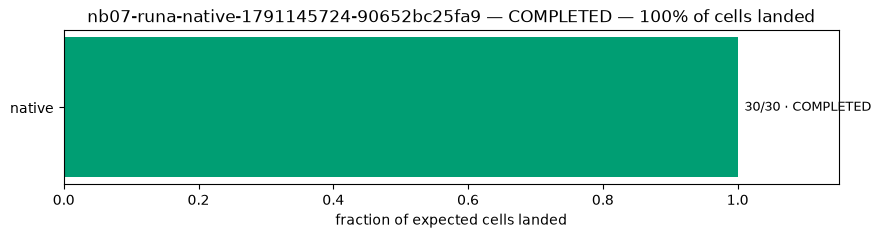

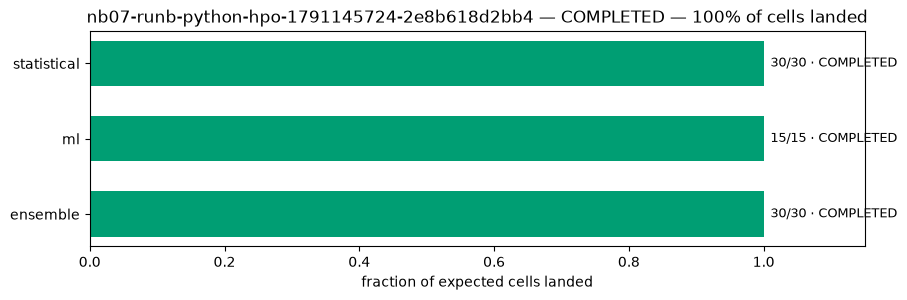

In [4]:
res_a = forecaster_a.run_live(poll_s=10.0, probe=True)
print(f"Run A complete: {res_a.run_id} ({res_a.status})")

res_b = forecaster_b.run_live(poll_s=15.0, probe=True)
print(f"Run B complete: {res_b.run_id} ({res_b.status})")

## Act 4 · Inspect Optuna Best Hyperparameters, Backtest Cohorts, Post-Run Re-Ensembling & Stacking Weights

1. `forecaster_b.best_params_df()` extracts the JSON `best_params` column from `forecast_metadata` so you can audit the hyperparameters selected by Optuna.
2. `forecaster_b.cohorts_df()` inspects backtest fold coverage (`v_backtest_coverage`) and comparable holdout-fold WAPE (`v_model_leaderboard_comparable`).
3. `forecaster_b.reensemble(strategies=['nnls', 'ridge', 'xgb'])` fits learned stacking meta-learners directly on Run B's stored out-of-fold predictions in BigQuery — **without re-running any base models!**
4. `forecaster_b.ensemble_weights_df()` and `forecaster_b.plot_ensemble_weights()` unpack the learned base-model stacking weights.

--- Optuna Tuned Hyperparameters (Run B) ---


,ts_id,model_type,compute_engine,is_ensemble,best_params_json,best_params,fit_seconds,wape,mae,rmse,mase
0,s_000000,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.077750,13.723405,16.986957,0.527141
1,s_000001,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,1.036905,3.006628,3.917155,0.933908
2,s_000002,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.050546,8.657889,10.273064,0.800881
3,s_000003,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.235623,18.241005,24.798916,0.651538
4,s_000004,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.519384,35.002823,43.993063,1.375440
5,s_000005,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.048133,9.907644,12.655375,0.284909
6,s_000006,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,1.082548,1.655029,2.213553,0.917789
7,s_000007,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.072235,10.648696,13.004278,1.005951
8,s_000008,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.249813,9.876696,20.759311,0.575230
9,s_000009,ensemble_nnls,ensemble,True,"{""holtwinters"": 0.4838362538178719, ""lightgbm""...","{'holtwinters': 0.4838362538178719, 'lightgbm'...",NaN,0.738357,42.632122,52.282902,1.336424


--- Backtest Cohort Health & Refit Modes (forecaster_b.cohorts_df) ---


,model_type,family,is_ensemble,n_series,score,pooled_wape,n_comparable_series,n_full,n_reduced,n_unscored,n_failed,n_not_requested,fold_histogram,refit_modes,staleness_gap
0,holtwinters,statistical,False,15,0.391809,0.156864,15,15,0,0,0,0,2f:15,per_fold:15,None
1,ensemble_ridge,ensemble,True,15,0.392641,0.137297,15,0,0,0,0,15,none,per_fold:15,None
2,ensemble_inverse_error,ensemble,True,15,0.395906,0.131573,15,0,0,0,0,15,none,per_fold:15,None
3,ensemble_nnls,ensemble,True,15,0.396686,0.135686,15,0,0,0,0,15,none,per_fold:15,None
4,ensemble_mean,ensemble,True,15,0.406978,0.139142,15,0,0,0,0,15,none,per_fold:15,None
5,ensemble_xgb,ensemble,True,15,0.410879,0.143773,15,0,0,0,0,15,none,per_fold:15,None
6,lightgbm,ml,False,15,0.431822,0.146606,15,15,0,0,0,0,2f:15,per_fold:15,None
7,theta,statistical,False,15,0.443389,0.158292,15,15,0,0,0,0,2f:15,per_fold:15,None


--- Post-Run Re-Ensembling on Run B (Adding nnls, ridge, xgb with zero model refits) ---


,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,holtwinters,statistical,False,None,vertex,15,wape,0.391809,0.156864,...,14.251815,19.000227,0.641667,74.878023,2.145524,2.313616,1.0,420,NaN,NaN
1,2,ensemble_ridge,ensemble,True,0ef348d159e6,ensemble,15,wape,0.392641,0.137297,...,12.743991,17.164181,NaN,NaN,NaN,NaN,0.0,1260,-0.000832,-0.002123
2,3,ensemble_inverse_error,ensemble,True,61cce757c612,ensemble,15,wape,0.395906,0.131573,...,12.163419,16.228268,NaN,NaN,NaN,NaN,1.0,0,-0.004096,-0.010455
3,4,ensemble_nnls,ensemble,True,0ef348d159e6,ensemble,15,wape,0.396686,0.135686,...,12.709427,17.054168,NaN,NaN,NaN,NaN,0.0,1260,-0.004877,-0.012447
4,5,ensemble_mean,ensemble,True,61cce757c612,ensemble,15,wape,0.406978,0.139142,...,13.060587,17.351793,NaN,NaN,NaN,NaN,1.0,0,-0.015169,-0.038715
5,6,ensemble_xgb,ensemble,True,0ef348d159e6,ensemble,15,wape,0.410879,0.143773,...,13.413725,17.719743,NaN,NaN,NaN,NaN,0.0,1260,-0.019070,-0.048671
6,7,lightgbm,ml,False,None,vertex,15,wape,0.431822,0.146606,...,13.382693,17.786898,0.284524,93.739764,1.060315,1.063863,1.0,420,NaN,NaN
7,8,theta,statistical,False,None,vertex,15,wape,0.443389,0.158292,...,14.614160,18.970049,0.995238,262.555232,4.567663,4.013818,1.0,420,NaN,NaN


--- Learned Ensemble Base-Model Weights (forecaster_b.ensemble_weights_df) ---


,ts_id,ensemble_model,strategy,base_model,weight,wape
0,s_000000,ensemble_nnls,nnls,holtwinters,0.483836,0.077750
1,s_000000,ensemble_nnls,nnls,lightgbm,0.553229,0.077750
2,s_000000,ensemble_nnls,nnls,theta,0.000000,0.077750
3,s_000001,ensemble_nnls,nnls,holtwinters,0.483836,1.036905
4,s_000001,ensemble_nnls,nnls,lightgbm,0.553229,1.036905
...,...,...,...,...,...,...
130,s_000013,ensemble_xgb,xgb,lightgbm,0.207832,0.136867
131,s_000013,ensemble_xgb,xgb,theta,0.446310,0.136867
132,s_000014,ensemble_xgb,xgb,holtwinters,0.345858,0.363079
133,s_000014,ensemble_xgb,xgb,lightgbm,0.207832,0.363079


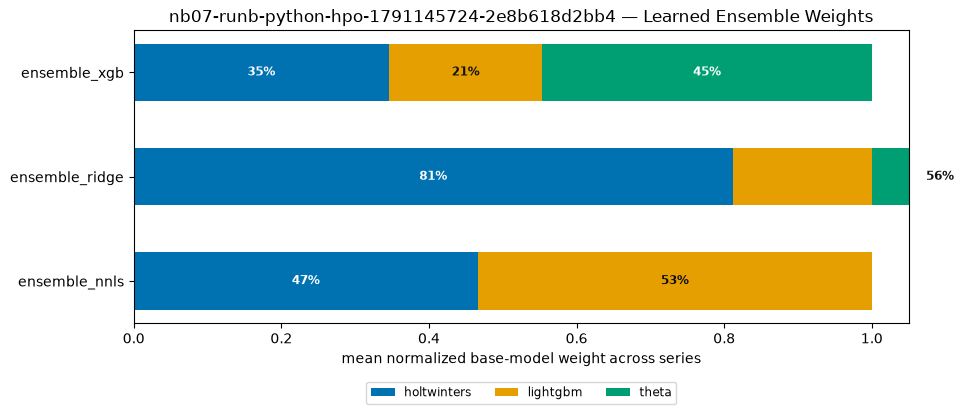

In [5]:
import matplotlib.pyplot as plt

print("--- Optuna Tuned Hyperparameters (Run B) ---")
display(forecaster_b.best_params_df().head(10))

print("--- Backtest Cohort Health & Refit Modes (forecaster_b.cohorts_df) ---")
display(forecaster_b.cohorts_df())

print("--- Post-Run Re-Ensembling on Run B (Adding nnls, ridge, xgb with zero model refits) ---")
forecaster_b.reensemble(strategies=["nnls", "ridge", "xgb"])
display(forecaster_b.leaderboard_df())

print("--- Learned Ensemble Base-Model Weights (forecaster_b.ensemble_weights_df) ---")
display(forecaster_b.ensemble_weights_df())
forecaster_b.plot_ensemble_weights()
plt.show()

## Act 5 · Cross-Run Ensembling (`forecaster_b.ensemble_runs()`)

Now let's combine the BigQuery SQL models from **Run A** (`arima_plus`, `timesfm`) with the Optuna-tuned Python models from **Run B** (`theta`, `holtwinters`, `lightgbm`) into a single composite run using `forecaster_b.ensemble_runs([res_a.run_id])`!

Under the hood, `ensemble_cross_runs()`:
1. Verifies that Run A and Run B share the same source table, frequency, horizon, and backtest geometry (`merge_configs_for_ensemble`).
2. Copies the base model rows (`forecast_metadata`, `forecast_predictions`, `backtest_oof`) from both source runs into a new composite `run_id`.
3. Fits `inverse_error`, `nnls`, `ridge`, and `xgb` across the combined 5-model pool in seconds!

Cross-run composite run_id: nb07-runb-python-hpo-1791145724-19b23c07b49c


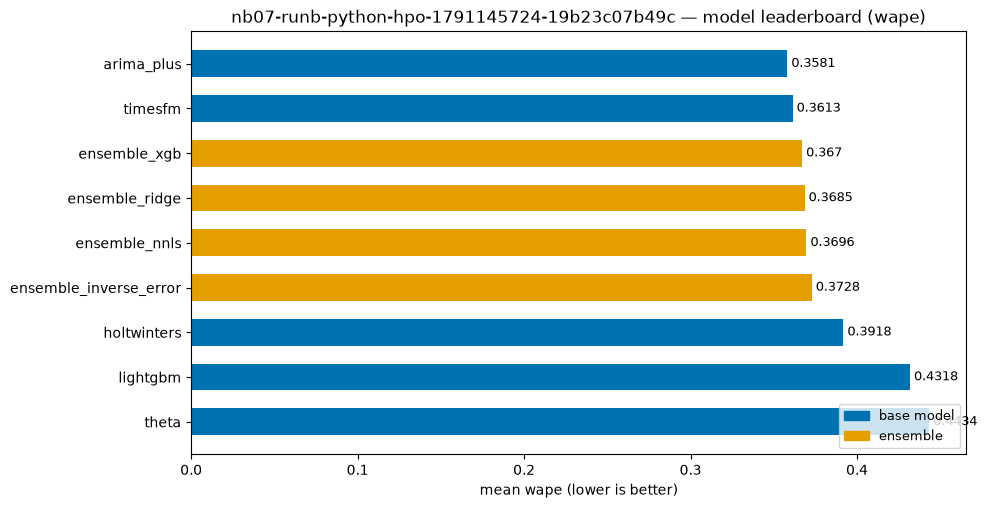

,ts_id,ensemble_model,strategy,base_model,weight,wape
0,s_000000,ensemble_nnls,nnls,arima_plus,0.704882,0.042847
1,s_000000,ensemble_nnls,nnls,holtwinters,0.000000,0.042847
2,s_000000,ensemble_nnls,nnls,lightgbm,0.299804,0.042847
3,s_000000,ensemble_nnls,nnls,theta,0.000000,0.042847
4,s_000000,ensemble_nnls,nnls,timesfm,0.000000,0.042847
...,...,...,...,...,...,...
220,s_000014,ensemble_xgb,xgb,arima_plus,0.316236,0.295120
221,s_000014,ensemble_xgb,xgb,holtwinters,0.156508,0.295120
222,s_000014,ensemble_xgb,xgb,lightgbm,0.198328,0.295120
223,s_000014,ensemble_xgb,xgb,theta,0.036464,0.295120


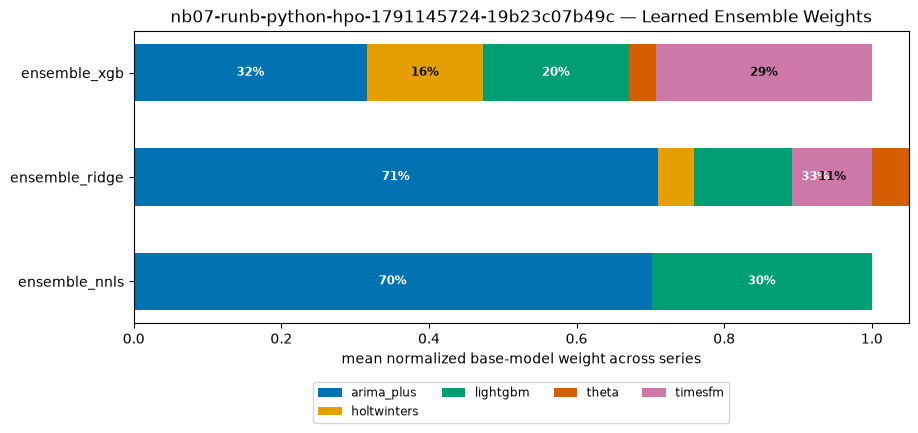

In [6]:
from scale_forecasting import plot_leaderboard, review_run

combined_run_id = forecaster_b.ensemble_runs(
    [res_a.run_id],
    strategies=["inverse_error", "nnls", "ridge", "xgb"],
)
print("Cross-run composite run_id:", combined_run_id)

combined_review = review_run(combined_run_id, settings=settings)
plot_leaderboard(combined_review)
plt.show()

combined_forecaster = Forecaster.from_run_id(combined_run_id, settings=settings)
display(combined_forecaster.ensemble_weights_df())
combined_forecaster.plot_ensemble_weights()
plt.show()